In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Conv2D, MaxPooling2D, GlobalAveragePooling2D,
                                     BatchNormalization, Dense, Reshape, Dropout, Input)
from tensorflow.keras.optimizers import Adam
import numpy as np

from tensorflow.keras.layers import Dropout

def build_hybrid_model(input_shape=(90, 34), num_classes=2):
    model = Sequential([
        # --- GIAI ĐOẠN PRE-PROCESSING ---
        Input(shape=input_shape),

        # --- GIAI ĐOẠN LSTM ---
        LSTM(32, return_sequences=True), # Tăng lên 64 neurons để giữ thông tin tốt hơn
        #Dropout(0.2), # Dropout 20% để tránh phụ thuộc quá mức vào các khớp đơn lẻ

        LSTM(32, return_sequences=True),
        #Dropout(0.2),

        # --- CHUYỂN ĐỔI ---
        # Lưu ý: Nếu dùng LSTM(64), reshape phải là (90, 64, 1)
        Reshape((90, 32, 1)),

        # --- GIAI ĐOẠN CONVOLUTION ---
        Conv2D(64, kernel_size=(5, 5), strides=(2, 2), padding='same', activation='relu'),
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        #Dropout(0.3), # Dropout sau CNN để làm mịn các bản đồ đặc trưng

        Conv2D(128, kernel_size=(3, 3), strides=(1, 1), padding='same', activation='relu'),
        # Không cần pooling ở đây vì chúng ta dùng GAP phía sau

        # --- GIAI ĐOẠN KẾT THÚC ---
        GlobalAveragePooling2D(),

        # BatchNormalization giúp ổn định giá trị trước khi vào lớp phân loại
        BatchNormalization(),

        # Lớp Dropout quan trọng nhất (0.5) ngay trước lớp quyết định
        #Dropout(0.5),

        Dense(num_classes, activation='softmax')
    ])

    return model

# Khởi tạo mô hình
model = build_hybrid_model()

# 2. Khởi tạo Optimizer với Learning Rate mong muốn
opt = Adam(learning_rate=0.0001)

# 3. Biên dịch mô hình
model.compile(
    optimizer=opt, # Truyền đối tượng opt đã cài đặt LR vào đây
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 90, 32)         │         8,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 90, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 90, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 45, 16, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 22, 8, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 22, 8, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,186 (364.01 KB)

 Trainable params: 92,930 (363.01 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.5714 - loss: 0.6901

17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 277ms/step - accuracy: 0.5974 - loss: 0.6862 - val_accuracy: 0.5784 - val_loss: 0.6928
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 333ms/step - accuracy: 0.6086 - loss: 0.6713 - val_accuracy: 0.4776 - val_loss: 0.6930
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.6114 - loss: 0.6618

17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 248ms/step - accuracy: 0.6292 - loss: 0.6592 - val_accuracy: 0.5299 - val_loss: 0.6920
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.6491 - loss: 0.6492

17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 247ms/step - accuracy: 0.6423 - loss: 0.6448 - val_accuracy: 0.5672 - val_loss: 0.6909
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.6459 - loss: 0.6296

17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 292ms/step - accuracy: 0.6423 - loss: 0.6281 - val_accuracy: 0.6119 - val_loss: 0.6890
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.6435 - loss: 0.6126

...

17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 333ms/step - accuracy: 0.8296 - loss: 0.3915 - val_accuracy: 0.8246 - val_loss: 0.4147
Epoch 83/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 250ms/step - accuracy: 0.8155 - loss: 0.4057 - val_accuracy: 0.6866 - val_loss: 0.6101
Epoch 84/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.8343 - loss: 0.4152

17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 336ms/step - accuracy: 0.8249 - loss: 0.4020 - val_accuracy: 0.8246 - val_loss: 0.4092
Epoch 85/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 248ms/step - accuracy: 0.8361 - loss: 0.3944 - val_accuracy: 0.7239 - val_loss: 0.5688
Epoch 86/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 281ms/step - accuracy: 0.8361 - loss: 0.3800 - val_accuracy: 0.7537 - val_loss: 0.5187
Epoch 87/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 299ms/step - accuracy: 0.8230 - loss: 0.3933 - val_accuracy: 0.5261 - val_loss: 1.2415
Epoch 88/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.8256 - loss: 0.3937

17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 260ms/step - accuracy: 0.8296 - loss: 0.3933 - val_accuracy: 0.8507 - val_loss: 0.3963
Epoch 89/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 328ms/step - accuracy: 0.8268 - loss: 0.3949 - val_accuracy: 0.7276 - val_loss: 0.5487
Epoch 90/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 254ms/step - accuracy: 0.8436 - loss: 0.3756 - val_accuracy: 0.7164 - val_loss: 0.6064
Epoch 91/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.8193 - loss: 0.4212

17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 249ms/step - accuracy: 0.8390 - loss: 0.3868 - val_accuracy: 0.8358 - val_loss: 0.3902
Epoch 92/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 336ms/step - accuracy: 0.8333 - loss: 0.3935 - val_accuracy: 0.4813 - val_loss: 2.1018
Epoch 93/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 243ms/step - accuracy: 0.8352 - loss: 0.3835 - val_accuracy: 0.5896 - val_loss: 0.9211
Epoch 94/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 243ms/step - accuracy: 0.8202 - loss: 0.4122 - val_accuracy: 0.5037 - val_loss: 1.5002
Epoch 95/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 333ms/step - accuracy: 0.8427 - loss: 0.3738 - val_accuracy: 0.7836 - val_loss: 0.4309
Epoch 96/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 241ms/step - accuracy: 0.8530 - loss: 0.3605 - val_accuracy: 0.8022 - val_loss: 0.4080
Epoch 97/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.8619 - loss: 0.3627

17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 245ms/step - accuracy: 0.8539 - loss: 0.3681 - val_accuracy: 0.8694 - val_loss: 0.3634
Epoch 98/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 323ms/step - accuracy: 0.8474 - loss: 0.3652 - val_accuracy: 0.7052 - val_loss: 0.6473
Epoch 99/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 287ms/step - accuracy: 0.8436 - loss: 0.3663 - val_accuracy: 0.7836 - val_loss: 0.4221
Epoch 100/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 266ms/step - accuracy: 0.8493 - loss: 0.3767 - val_accuracy: 0.7463 - val_loss: 0.5825


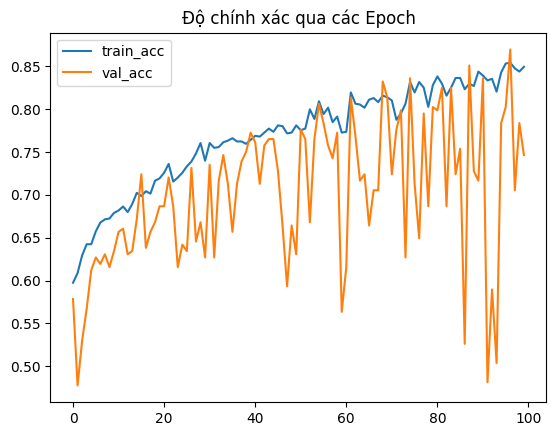

In [7]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. Load dữ liệu từ file .npy
# X có hình dạng (N, 90, 34), y có hình dạng (N,)
X = np.load('X_data.npy')
y = np.load('y_data.npy')

# 2. Chia dữ liệu (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Cấu hình Callback (Lưu model tốt nhất và dừng sớm nếu không cải thiện)
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_hybrid_model.h5", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# 4. Huấn luyện
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=callbacks
)

# 5. Vẽ đồ thị kết quả
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Độ chính xác qua các Epoch")
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 258ms/step
CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Normal       0.85      0.88      0.86       127
 Shoplifting       0.89      0.86      0.87       141

    accuracy                           0.87       268
   macro avg       0.87      0.87      0.87       268
weighted avg       0.87      0.87      0.87       268



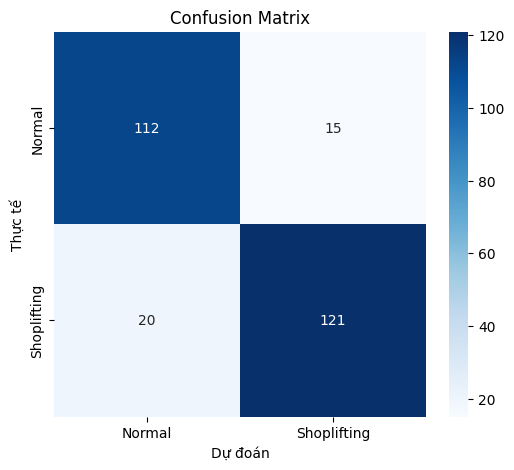

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Dự đoán trên tập test
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1) # Chuyển từ xác suất sang nhãn 0, 1

# 2. In báo cáo chi tiết
print("CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_classes, target_names=['Normal', 'Shoplifting']))

# 3. Vẽ Confusion Matrix (Ma trận nhầm lẫn)
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Shoplifting'],
            yticklabels=['Normal', 'Shoplifting'])
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Confusion Matrix')
plt.show()